In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Reproducibility — set random seed everywhere
RANDOM_STATE = 42

print("Imports successful.")

Imports successful.


In [2]:
# Cell 2 — Reload data (independent of EDA notebook)
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

df = pd.read_csv(
    '../data/raw/heart_disease.csv',
    names=column_names,
    na_values='?'
)

# Binarize target (same as EDA)
df['target_binary'] = (df['target'] > 0).astype(int)

# Drop the original 5-class target
df = df.drop(columns=['target'])

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['target_binary'].value_counts()}")
df.head()

Dataset shape: (303, 14)
Target distribution:
target_binary
0    164
1    139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target_binary
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Cell 3 — Train/test split BEFORE any preprocessing
# This is the most important "do not skip" step in ML.

# Separate features (X) and target (y)
X = df.drop(columns=['target_binary'])
y = df['target_binary']

# 80/20 split, stratified to preserve class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # ← critical for classification
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

X_train shape: (242, 13)
X_test shape:  (61, 13)

Train class balance:
target_binary
0    0.541
1    0.459
Name: proportion, dtype: float64

Test class balance:
target_binary
0    0.541
1    0.459
Name: proportion, dtype: float64


In [4]:
# Cell 4 — Classify columns as numerical vs. categorical
# This dictates how each feature gets preprocessed.

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Total: {len(numerical_cols) + len(categorical_cols)} (should match 13)")

Numerical features (5): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical features (8): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Total: 13 (should match 13)


In [5]:
# Cell 5 — Imputation
# Recall: ca has 4 missing, thal has 2 missing in the full dataset.
# We FIT the imputer on training data only, then APPLY to both.0

# Numerical: median imputation (robust to outliers)
num_imputer = SimpleImputer(strategy='median')
X_train_num = num_imputer.fit_transform(X_train[numerical_cols])
X_test_num = num_imputer.transform(X_test[numerical_cols])

# Categorical: mode (most frequent) imputation
cat_imputer = SimpleImputer(strategy='most_frequent')
X_train_cat = cat_imputer.fit_transform(X_train[categorical_cols])
X_test_cat = cat_imputer.transform(X_test[categorical_cols])

# Reassemble into DataFrames (we lose column names through SimpleImputer; restore them)
X_train_imputed = pd.concat([
    pd.DataFrame(X_train_num, columns=numerical_cols, index=X_train.index),
    pd.DataFrame(X_train_cat, columns=categorical_cols, index=X_train.index)
], axis=1)

X_test_imputed = pd.concat([
    pd.DataFrame(X_test_num, columns=numerical_cols, index=X_test.index),
    pd.DataFrame(X_test_cat, columns=categorical_cols, index=X_test.index)
], axis=1)

# Verify no NaN remains
print(f"NaN in X_train_imputed: {X_train_imputed.isnull().sum().sum()}")
print(f"NaN in X_test_imputed:  {X_test_imputed.isnull().sum().sum()}")

print(f"\nX_train_imputed shape: {X_train_imputed.shape}")
X_train_imputed.head()

NaN in X_train_imputed: 0
NaN in X_test_imputed:  0

X_train_imputed shape: (242, 13)


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
180,48.0,124.0,274.0,166.0,0.5,1.0,4.0,0.0,2.0,0.0,2.0,0.0,7.0
208,55.0,130.0,262.0,155.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,3.0
167,54.0,132.0,288.0,159.0,0.0,0.0,2.0,1.0,2.0,1.0,1.0,1.0,3.0
105,54.0,108.0,309.0,156.0,0.0,1.0,2.0,0.0,0.0,0.0,1.0,0.0,7.0
297,57.0,140.0,241.0,123.0,0.2,0.0,4.0,0.0,0.0,1.0,2.0,0.0,7.0


In [6]:
# Cell 6 — Track A: Tree-friendly data (no scaling, no one-hot)
# For Random Forest and XGBoost.

X_train_tree = X_train_imputed.copy()
X_test_tree = X_test_imputed.copy()

print(f"X_train_tree shape: {X_train_tree.shape}")
print(f"X_test_tree shape:  {X_test_tree.shape}")
print("\nFirst row, raw values intact:")
X_train_tree.head(1)

X_train_tree shape: (242, 13)
X_test_tree shape:  (61, 13)

First row, raw values intact:


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal
180,48.0,124.0,274.0,166.0,0.5,1.0,4.0,0.0,2.0,0.0,2.0,0.0,7.0


In [7]:
# Cell 7 — One-hot encode categoricals (for linear, SVM, NN models)
# pd.get_dummies converts each category value into its own 0/1 column.

X_train_oh = pd.get_dummies(
    X_train_imputed,
    columns=categorical_cols,
    drop_first=True   # drops one category per feature to avoid multicollinearity
).astype(float)

X_test_oh = pd.get_dummies(
    X_test_imputed,
    columns=categorical_cols,
    drop_first=True
).astype(float)

# Critical: align columns between train and test
# If a category appears in train but not in test (or vice versa), the column counts won't match.
# This realigns them, filling missing columns with 0.
X_train_oh, X_test_oh = X_train_oh.align(X_test_oh, join='left', axis=1, fill_value=0)

print(f"X_train_oh shape: {X_train_oh.shape}")
print(f"X_test_oh shape:  {X_test_oh.shape}")
print(f"\nNew columns after one-hot encoding:")
print(list(X_train_oh.columns))

X_train_oh shape: (242, 20)
X_test_oh shape:  (61, 20)

New columns after one-hot encoding:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_1.0', 'restecg_1.0', 'restecg_2.0', 'exang_1.0', 'slope_2.0', 'slope_3.0', 'ca_1.0', 'ca_2.0', 'ca_3.0', 'thal_6.0', 'thal_7.0']


In [8]:
# Cell 8 — Scale numerical features (z-score normalization)
# StandardScaler: subtract mean, divide by std. Each feature ends up mean 0, std 1.

scaler = StandardScaler()

# Fit on training, transform both — same pattern as imputation
X_train_scaled = X_train_oh.copy()
X_test_scaled = X_test_oh.copy()

X_train_scaled[numerical_cols] = scaler.fit_transform(X_train_oh[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test_oh[numerical_cols])

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"\nNumerical columns AFTER scaling (should be ~mean 0, ~std 1):")
print(X_train_scaled[numerical_cols].describe().round(3).loc[['mean', 'std']])

print(f"\nFirst row of scaled data:")
X_train_scaled.head(1)

X_train_scaled shape: (242, 20)

Numerical columns AFTER scaling (should be ~mean 0, ~std 1):
        age  trestbps   chol  thalach  oldpeak
mean -0.000    -0.000  0.000   -0.000    0.000
std   1.002     1.002  1.002    1.002    1.002

First row of scaled data:


,age,trestbps,chol,thalach,oldpeak,sex_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_1.0,restecg_1.0,restecg_2.0,exang_1.0,slope_2.0,slope_3.0,ca_1.0,ca_2.0,ca_3.0,thal_6.0,thal_7.0
180,-0.729485,-0.395692,0.458139,0.708371,-0.445445,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [9]:
# Cell 9 — SMOTE on training set ONLY
# Generates synthetic minority-class samples via interpolation.
# Test set must reflect real-world class distribution — never SMOTE it.

from collections import Counter

print("BEFORE SMOTE:")
print(f"  Train class distribution: {Counter(y_train)}")
print(f"  X_train_tree shape: {X_train_tree.shape}")
print(f"  X_train_scaled shape: {X_train_scaled.shape}")

smote = SMOTE(random_state=RANDOM_STATE)

# Apply SMOTE to BOTH preprocessing tracks
X_train_tree_sm, y_train_tree_sm = smote.fit_resample(X_train_tree, y_train)
X_train_scaled_sm, y_train_scaled_sm = smote.fit_resample(X_train_scaled, y_train)

print("\nAFTER SMOTE:")
print(f"  Train class distribution (tree track):   {Counter(y_train_tree_sm)}")
print(f"  Train class distribution (scaled track): {Counter(y_train_scaled_sm)}")
print(f"  X_train_tree_sm shape: {X_train_tree_sm.shape}")
print(f"  X_train_scaled_sm shape: {X_train_scaled_sm.shape}")

print(f"\nTest set untouched (verify):")
print(f"  Test class distribution: {Counter(y_test)}")
print(f"  X_test_tree shape: {X_test_tree.shape}")
print(f"  X_test_scaled shape: {X_test_scaled.shape}")

BEFORE SMOTE:
  Train class distribution: Counter({0: 131, 1: 111})
  X_train_tree shape: (242, 13)
  X_train_scaled shape: (242, 20)

AFTER SMOTE:
  Train class distribution (tree track):   Counter({1: 131, 0: 131})
  Train class distribution (scaled track): Counter({1: 131, 0: 131})
  X_train_tree_sm shape: (262, 13)
  X_train_scaled_sm shape: (262, 20)

Test set untouched (verify):
  Test class distribution: Counter({0: 33, 1: 28})
  X_test_tree shape: (61, 13)
  X_test_scaled shape: (61, 20)


In [10]:
# Cell 10 — Save processed datasets to data/processed/
import os

os.makedirs('../data/processed', exist_ok=True)

# Tree track (post-SMOTE train, untouched test)
X_train_tree_sm.to_csv('../data/processed/X_train_tree.csv', index=False)
X_test_tree.to_csv('../data/processed/X_test_tree.csv', index=False)

# Scaled track (post-SMOTE train, untouched test)
X_train_scaled_sm.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)

# Targets
pd.Series(y_train_tree_sm, name='target').to_csv('../data/processed/y_train_tree.csv', index=False)
pd.Series(y_train_scaled_sm, name='target').to_csv('../data/processed/y_train_scaled.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("Saved 7 files to data/processed/:")
for f in sorted(os.listdir('../data/processed')):
    size = os.path.getsize(f'../data/processed/{f}') / 1024
    print(f"  {f}  ({size:.1f} KB)")

Saved 7 files to data/processed/:
  X_test_scaled.csv  (9.7 KB)
  X_test_tree.csv  (3.6 KB)
  X_train_scaled.csv  (41.5 KB)
  X_train_tree.csv  (17.6 KB)
  y_test.csv  (0.2 KB)
  y_train_scaled.csv  (0.8 KB)
  y_train_tree.csv  (0.8 KB)


In [11]:
# Cell 11 — MLflow setup and verification
import mlflow
import mlflow.sklearn
from datetime import datetime

# Set the tracking URI to the local MLflow server we just launched
mlflow.set_tracking_uri('http://localhost:5000')

# Create an experiment for this project (or reuse if it exists)
EXPERIMENT_NAME = 'patient-risk-stratification'
mlflow.set_experiment(EXPERIMENT_NAME)

# Verify connection with a test run
with mlflow.start_run(run_name='setup_verification'):
    mlflow.log_param('test_param', 'pipeline_ready')
    mlflow.log_metric('test_metric', 1.0)
    mlflow.log_param('preprocessing_completed', datetime.now().isoformat())
    mlflow.log_param('train_samples_after_smote', 262)
    mlflow.log_param('test_samples', 61)
    mlflow.log_param('features_tree', 13)
    mlflow.log_param('features_scaled', 20)

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")
print("Setup verification run logged successfully.")
print("\nRefresh http://localhost:5000 — you should see one run under 'patient-risk-stratification'.")

🏃 View run setup_verification at: http://localhost:5000/#/experiments/1/runs/2686e1ff1e44425895695e441b40b9b1
🧪 View experiment at: http://localhost:5000/#/experiments/1
MLflow tracking URI: http://localhost:5000
Experiment: patient-risk-stratification
Setup verification run logged successfully.

Refresh http://localhost:5000 — you should see one run under 'patient-risk-stratification'.


In [12]:
# Cell 12 — Modeling imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, roc_curve, average_precision_score
)

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.pytorch

print("Modeling imports successful.")
print(f"PyTorch version: {torch.__version__}")
print(f"XGBoost version: {xgb.__version__}")

Modeling imports successful.
PyTorch version: 2.11.0+cpu
XGBoost version: 3.2.0


In [13]:
# Cell 13 — Helper to evaluate a model and log to MLflow

def evaluate_and_log(
    model_name,
    model,
    X_train, y_train,
    X_test, y_test,
    hyperparams=None,
    flavor='sklearn'
):
    """
    Evaluate a fitted model on test set, log everything to MLflow.
    
    flavor: 'sklearn', 'xgboost', or 'pytorch' — controls how model is saved.
    """
    with mlflow.start_run(run_name=model_name):
        # Log hyperparameters
        if hyperparams:
            for k, v in hyperparams.items():
                mlflow.log_param(k, v)
        mlflow.log_param('model_type', model_name)
        mlflow.log_param('train_samples', len(X_train))
        mlflow.log_param('test_samples', len(X_test))

        # Predictions
        y_pred = model.predict(X_test)

        # Probabilities — needed for AUC and PR-AUC
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        elif hasattr(model, 'decision_function'):
            # SVM with probability=False uses decision_function
            y_pred_proba = model.decision_function(X_test)
        else:
            y_pred_proba = y_pred  # fallback

        # Metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba),
            'pr_auc': average_precision_score(y_test, y_pred_proba),
        }

        for k, v in metrics.items():
            mlflow.log_metric(k, v)

        # Log the model artifact (so it can be loaded later)
        if flavor == 'sklearn':
            mlflow.sklearn.log_model(model, name='model')
        elif flavor == 'xgboost':
            mlflow.xgboost.log_model(model, name='model')
        elif flavor == 'pytorch':
            mlflow.pytorch.log_model(model, name='model')

        # Print summary
        print(f"\n{'=' * 50}")
        print(f"{model_name}")
        print('=' * 50)
        for k, v in metrics.items():
            print(f"  {k:12s}: {v:.4f}")

        return metrics

print("Helper function defined.")

Helper function defined.


In [14]:
# Cell 14 — Load processed data
# (We could use the in-memory variables from Block 2, but loading from disk
# proves the saved files are good and makes this cell reusable.)

X_train_tree = pd.read_csv('../data/processed/X_train_tree.csv')
X_test_tree = pd.read_csv('../data/processed/X_test_tree.csv')
y_train_tree = pd.read_csv('../data/processed/y_train_tree.csv')['target']

X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')
y_train_scaled = pd.read_csv('../data/processed/y_train_scaled.csv')['target']

y_test = pd.read_csv('../data/processed/y_test.csv')['target_binary']

print("Tree track:")
print(f"  X_train_tree:   {X_train_tree.shape}, y_train_tree: {y_train_tree.shape}")
print(f"  X_test_tree:    {X_test_tree.shape}")

print("\nScaled track:")
print(f"  X_train_scaled: {X_train_scaled.shape}, y_train_scaled: {y_train_scaled.shape}")
print(f"  X_test_scaled:  {X_test_scaled.shape}")

print(f"\nTest target: {y_test.shape}, distribution: {y_test.value_counts().to_dict()}")

Tree track:
  X_train_tree:   (262, 13), y_train_tree: (262,)
  X_test_tree:    (61, 13)

Scaled track:
  X_train_scaled: (262, 20), y_train_scaled: (262,)
  X_test_scaled:  (61, 20)

Test target: (61,), distribution: {0: 33, 1: 28}


In [15]:
# Cell 15 — Model 1: Logistic Regression (scaled track)

# Hyperparameters
lr_params = {
    'C': 1.0,                    # inverse of regularization strength; 1.0 = default balance
    'max_iter': 1000,            # higher than default to ensure convergence on small datasets
    'random_state': RANDOM_STATE,
    'solver': 'lbfgs',           # default solver; works well for small/medium datasets
}

lr_model = LogisticRegression(**lr_params)
lr_model.fit(X_train_scaled, y_train_scaled)

lr_metrics = evaluate_and_log(
    model_name='LogisticRegression',
    model=lr_model,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test,
    hyperparams=lr_params,
    flavor='sklearn'
)

2026/04/26 21:13:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LogisticRegression
  accuracy    : 0.8689
  precision   : 0.8333
  recall      : 0.8929
  f1          : 0.8621
  roc_auc     : 0.9610
  pr_auc      : 0.9581
🏃 View run LogisticRegression at: http://localhost:5000/#/experiments/1/runs/e09e7eff73874f5dad8195de495a603b
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [16]:
# Cell 16 — Model 2: Random Forest (tree track)

rf_params = {
    'n_estimators': 200,         # 200 trees — more trees = more stable, diminishing returns past ~500
    'max_depth': 10,             # cap tree depth to prevent overfitting on small data
    'min_samples_split': 5,      # require at least 5 samples to split a node
    'min_samples_leaf': 2,       # require at least 2 samples per leaf
    'class_weight': 'balanced',  # safety net even though we SMOTE'd
    'random_state': RANDOM_STATE,
    'n_jobs': -1,                # use all CPU cores
}

rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_train_tree, y_train_tree)

rf_metrics = evaluate_and_log(
    model_name='RandomForest',
    model=rf_model,
    X_train=X_train_tree,
    y_train=y_train_tree,
    X_test=X_test_tree,
    y_test=y_test,
    hyperparams=rf_params,
    flavor='sklearn'
)

2026/04/26 21:13:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



RandomForest
  accuracy    : 0.9016
  precision   : 0.8438
  recall      : 0.9643
  f1          : 0.9000
  roc_auc     : 0.9643
  pr_auc      : 0.9551
🏃 View run RandomForest at: http://localhost:5000/#/experiments/1/runs/5ffc3f32bc65475ca9a8a82bfa7854c5
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [17]:
# Cell 17 — Model 3: XGBoost (tree track)

xgb_params = {
    'n_estimators': 200,          # number of boosting rounds
    'max_depth': 5,               # individual tree depth — shallower than RF (boosting doesn't need deep trees)
    'learning_rate': 0.1,         # how aggressively each tree corrects the previous
    'subsample': 0.8,             # use 80% of rows per tree (regularization via row sampling)
    'colsample_bytree': 0.8,      # use 80% of columns per tree (regularization via feature sampling)
    'eval_metric': 'logloss',     # what to optimize during training
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train_tree, y_train_tree)

xgb_metrics = evaluate_and_log(
    model_name='XGBoost',
    model=xgb_model,
    X_train=X_train_tree,
    y_train=y_train_tree,
    X_test=X_test_tree,
    y_test=y_test,
    hyperparams=xgb_params,
    flavor='xgboost'
)


XGBoost
  accuracy    : 0.8689
  precision   : 0.8125
  recall      : 0.9286
  f1          : 0.8667
  roc_auc     : 0.9448
  pr_auc      : 0.9063
🏃 View run XGBoost at: http://localhost:5000/#/experiments/1/runs/acec3ca161014f5ab2a85f185a2c563d
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [18]:
# Cell 18 — Model 4: SVM with RBF kernel (scaled track)

svm_params = {
    'kernel': 'rbf',             # Radial Basis Function — captures non-linear boundaries
    'C': 1.0,                    # regularization (same C as LR — inverse strength)
    'gamma': 'scale',            # kernel coefficient; 'scale' = 1/(n_features * X.var())
    'probability': True,         # enable predict_proba() for AUC computation
    'random_state': RANDOM_STATE,
}

svm_model = SVC(**svm_params)
svm_model.fit(X_train_scaled, y_train_scaled)

svm_metrics = evaluate_and_log(
    model_name='SVM_RBF',
    model=svm_model,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test,
    hyperparams=svm_params,
    flavor='sklearn'
)

2026/04/26 21:14:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



SVM_RBF
  accuracy    : 0.9016
  precision   : 0.8438
  recall      : 0.9643
  f1          : 0.9000
  roc_auc     : 0.9697
  pr_auc      : 0.9632
🏃 View run SVM_RBF at: http://localhost:5000/#/experiments/1/runs/e7463ca81d11454181b6fcf820b52453
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [19]:
# Cell 19 — Model 5: PyTorch Neural Network architecture

class HeartDiseaseNN(nn.Module):
    """
    Simple feedforward neural network for binary classification.
    Architecture: 20 inputs → 32 hidden → 16 hidden → 1 output (sigmoid)
    """
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.3),       # randomly zero 30% of neurons during training
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 1),
            nn.Sigmoid()           # output a probability between 0 and 1
        )

    def forward(self, x):
        return self.net(x)

# Verify by instantiating
nn_model_check = HeartDiseaseNN(input_dim=X_train_scaled.shape[1])
print(nn_model_check)
print(f"\nTotal parameters: {sum(p.numel() for p in nn_model_check.parameters())}")

HeartDiseaseNN(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)

Total parameters: 1217


Epoch  10/50: loss = 0.6108
Epoch  20/50: loss = 0.4615
Epoch  30/50: loss = 0.3942
Epoch  40/50: loss = 0.3333
Epoch  50/50: loss = 0.3526

Training complete.


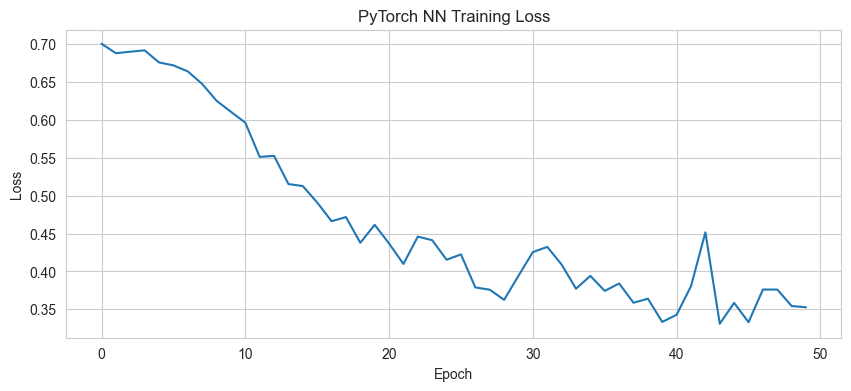

In [20]:
# Cell 20 — PyTorch training loop

# Convert pandas DataFrames to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_scaled.values)
y_train_tensor = torch.FloatTensor(y_train_scaled.values).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test_scaled.values)

# DataLoader handles batching automatically
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Hyperparameters
nn_params = {
    'input_dim': X_train_scaled.shape[1],
    'hidden1': 32,
    'hidden2': 16,
    'dropout': 0.3,
    'learning_rate': 0.001,
    'batch_size': 32,
    'epochs': 50,
}

# Set seeds for reproducibility
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Build, optimizer, loss
nn_model = HeartDiseaseNN(input_dim=nn_params['input_dim'])
optimizer = torch.optim.Adam(nn_model.parameters(), lr=nn_params['learning_rate'])
criterion = nn.BCELoss()  # Binary Cross-Entropy — the right loss for binary classification

# Training loop
nn_model.train()
losses = []
for epoch in range(nn_params['epochs']):
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()             # reset gradients
        y_pred_batch = nn_model(X_batch)  # forward pass
        loss = criterion(y_pred_batch, y_batch)
        loss.backward()                   # backward pass (compute gradients)
        optimizer.step()                  # update weights
        epoch_loss += loss.item()
    losses.append(epoch_loss / len(train_loader))
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{nn_params['epochs']}: loss = {losses[-1]:.4f}")

print("\nTraining complete.")

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('PyTorch NN Training Loss')
plt.grid(True)
plt.show()

In [21]:
# Cell 21 — Evaluate PyTorch NN on test set, log to MLflow

# Switch to evaluation mode (disables dropout)
nn_model.eval()

# Wrap predictions in our helper. PyTorch model needs a small adapter
# because predict() / predict_proba() aren't native to nn.Module.
class PyTorchSklearnAdapter:
    """Adapts a PyTorch model to a minimal sklearn-style API for our helper."""
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        with torch.no_grad():
            probs = self.model(torch.FloatTensor(X)).numpy().flatten()
        return (probs >= self.threshold).astype(int)

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        with torch.no_grad():
            probs = self.model(torch.FloatTensor(X)).numpy().flatten()
        # Return shape (n, 2) like sklearn classifiers
        return np.column_stack([1 - probs, probs])

nn_wrapped = PyTorchSklearnAdapter(nn_model)

nn_metrics = evaluate_and_log(
    model_name='PyTorch_NN',
    model=nn_wrapped,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test,
    hyperparams=nn_params,
    flavor='sklearn'   # ← changed from 'pytorch' to handle the wrapper
)

2026/04/26 21:14:21 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



PyTorch_NN
  accuracy    : 0.8852
  precision   : 0.8387
  recall      : 0.9286
  f1          : 0.8814
  roc_auc     : 0.9675
  pr_auc      : 0.9633
🏃 View run PyTorch_NN at: http://localhost:5000/#/experiments/1/runs/6482f0712e6049e1b8a0c669cec551cf
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [22]:
print(f"X_train_tree:   {X_train_tree.shape}")
print(f"X_test_tree:    {X_test_tree.shape}")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

print(f"\nModels in memory:")
print(f"  lr_model:  {type(lr_model).__name__}")
print(f"  rf_model:  {type(rf_model).__name__}")
print(f"  xgb_model: {type(xgb_model).__name__}")
print(f"  svm_model: {type(svm_model).__name__}")
print(f"  nn_model:  {type(nn_model).__name__}")

print(f"\nMetrics dicts:")
print(f"  lr_metrics, rf_metrics, xgb_metrics, svm_metrics, nn_metrics — all populated")

X_train_tree:   (262, 13)
X_test_tree:    (61, 13)
X_train_scaled: (262, 20)
X_test_scaled:  (61, 20)

Models in memory:
  lr_model:  LogisticRegression
  rf_model:  RandomForestClassifier
  xgb_model: XGBClassifier
  svm_model: SVC
  nn_model:  HeartDiseaseNN

Metrics dicts:
  lr_metrics, rf_metrics, xgb_metrics, svm_metrics, nn_metrics — all populated


In [23]:
# Cell 22 — RandomizedSearchCV on Random Forest
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter search space
rf_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', None],
}

# Search: 30 random combos × 5-fold CV = 150 fits total
rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=30,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Tuning Random Forest (30 combos × 5 folds = 150 fits)...")
rf_search.fit(X_train_tree, y_train_tree)

print(f"\nBest CV ROC-AUC: {rf_search.best_score_:.4f}")
print(f"Best parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")

# Evaluate the tuned model on test set, log to MLflow
rf_tuned = rf_search.best_estimator_
rf_tuned_metrics = evaluate_and_log(
    model_name='RandomForest_Tuned',
    model=rf_tuned,
    X_train=X_train_tree,
    y_train=y_train_tree,
    X_test=X_test_tree,
    y_test=y_test,
    hyperparams={**rf_search.best_params_, 'cv_folds': 5, 'n_iter': 30, 'cv_score': rf_search.best_score_},
    flavor='sklearn'
)

Tuning Random Forest (30 combos × 5 folds = 150 fits)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV ROC-AUC: 0.9062
Best parameters:
  class_weight: None
  max_depth: 5
  max_features: sqrt
  min_samples_leaf: 3
  min_samples_split: 8
  n_estimators: 120


2026/04/26 21:26:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



RandomForest_Tuned
  accuracy    : 0.9016
  precision   : 0.8667
  recall      : 0.9286
  f1          : 0.8966
  roc_auc     : 0.9578
  pr_auc      : 0.9426
🏃 View run RandomForest_Tuned at: http://localhost:5000/#/experiments/1/runs/875334c3714a4d758ae05297a34759e3
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [24]:
# Cell 23 — RandomizedSearchCV on SVM
svm_param_dist = {
    'C': uniform(0.1, 100),       # uniform between 0.1 and 100.1
    'gamma': uniform(0.001, 1),   # uniform between 0.001 and 1.001
    'kernel': ['rbf', 'poly'],
}

svm_search = RandomizedSearchCV(
    estimator=SVC(probability=True, random_state=RANDOM_STATE),
    param_distributions=svm_param_dist,
    n_iter=20,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Tuning SVM (20 combos × 5 folds = 100 fits)...")
svm_search.fit(X_train_scaled, y_train_scaled)

print(f"\nBest CV ROC-AUC: {svm_search.best_score_:.4f}")
print(f"Best parameters:")
for k, v in svm_search.best_params_.items():
    print(f"  {k}: {v}")

svm_tuned = svm_search.best_estimator_
svm_tuned_metrics = evaluate_and_log(
    model_name='SVM_Tuned',
    model=svm_tuned,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test,
    hyperparams={**svm_search.best_params_, 'cv_folds': 5, 'n_iter': 20, 'cv_score': svm_search.best_score_},
    flavor='sklearn'
)

Tuning SVM (20 combos × 5 folds = 100 fits)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best CV ROC-AUC: 0.8861
Best parameters:
  C: 0.8066305219717406
  gamma: 0.024062425041415758
  kernel: rbf


2026/04/26 21:33:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



SVM_Tuned
  accuracy    : 0.8852
  precision   : 0.8387
  recall      : 0.9286
  f1          : 0.8814
  roc_auc     : 0.9643
  pr_auc      : 0.9573
🏃 View run SVM_Tuned at: http://localhost:5000/#/experiments/1/runs/d7456a81bbdc49a08f9737d3d96e438e
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [25]:
# Cell 24 — RandomizedSearchCV on XGBoost
xgb_param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),         # samples between 0.6 and 1.0
    'colsample_bytree': uniform(0.6, 0.4),  # samples between 0.6 and 1.0
    'gamma': uniform(0, 5),                 # min loss reduction for split
    'reg_alpha': uniform(0, 1),             # L1 regularization
    'reg_lambda': uniform(0, 1),            # L2 regularization
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Tuning XGBoost (40 combos × 5 folds = 200 fits)...")
xgb_search.fit(X_train_tree, y_train_tree)

print(f"\nBest CV ROC-AUC: {xgb_search.best_score_:.4f}")
print(f"Best parameters:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")

xgb_tuned = xgb_search.best_estimator_
xgb_tuned_metrics = evaluate_and_log(
    model_name='XGBoost_Tuned',
    model=xgb_tuned,
    X_train=X_train_tree,
    y_train=y_train_tree,
    X_test=X_test_tree,
    y_test=y_test,
    hyperparams={**xgb_search.best_params_, 'cv_folds': 5, 'n_iter': 40, 'cv_score': xgb_search.best_score_},
    flavor='xgboost'
)

Tuning XGBoost (40 combos × 5 folds = 200 fits)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


C:\Users\shrik\Documents\patient-risk-stratification\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
3 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\shrik\Documents\patient-risk-stratification\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\shrik\Documents\patient-risk-stratification\venv\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
  File "C:\Users\shrik\Documents\patient-risk-


Best CV ROC-AUC: 0.8868
Best parameters:
  colsample_bytree: 0.7115485410368727
  gamma: 3.5017891498638565
  learning_rate: 0.26399834267149175
  max_depth: 6
  n_estimators: 251
  reg_alpha: 0.4045081271221901
  reg_lambda: 0.8877700987609598
  subsample: 0.9403713795070051

XGBoost_Tuned
  accuracy    : 0.8525
  precision   : 0.8065
  recall      : 0.8929
  f1          : 0.8475
  roc_auc     : 0.9491
  pr_auc      : 0.9468
🏃 View run XGBoost_Tuned at: http://localhost:5000/#/experiments/1/runs/9ce94c15ee034e9ab4fa178014b96444
🧪 View experiment at: http://localhost:5000/#/experiments/1


All model results:
                   accuracy  precision  recall      f1  roc_auc  pr_auc
LR                   0.8689     0.8333  0.8929  0.8621   0.9610  0.9581
RF (untuned)         0.9016     0.8438  0.9643  0.9000   0.9643  0.9551
XGBoost (untuned)    0.8689     0.8125  0.9286  0.8667   0.9448  0.9063
SVM (untuned)        0.9016     0.8438  0.9643  0.9000   0.9697  0.9632
NN                   0.8852     0.8387  0.9286  0.8814   0.9675  0.9633
RF (tuned)           0.9016     0.8667  0.9286  0.8966   0.9578  0.9426
SVM (tuned)          0.8852     0.8387  0.9286  0.8814   0.9643  0.9573
XGBoost (tuned)      0.8525     0.8065  0.8929  0.8475   0.9491  0.9468


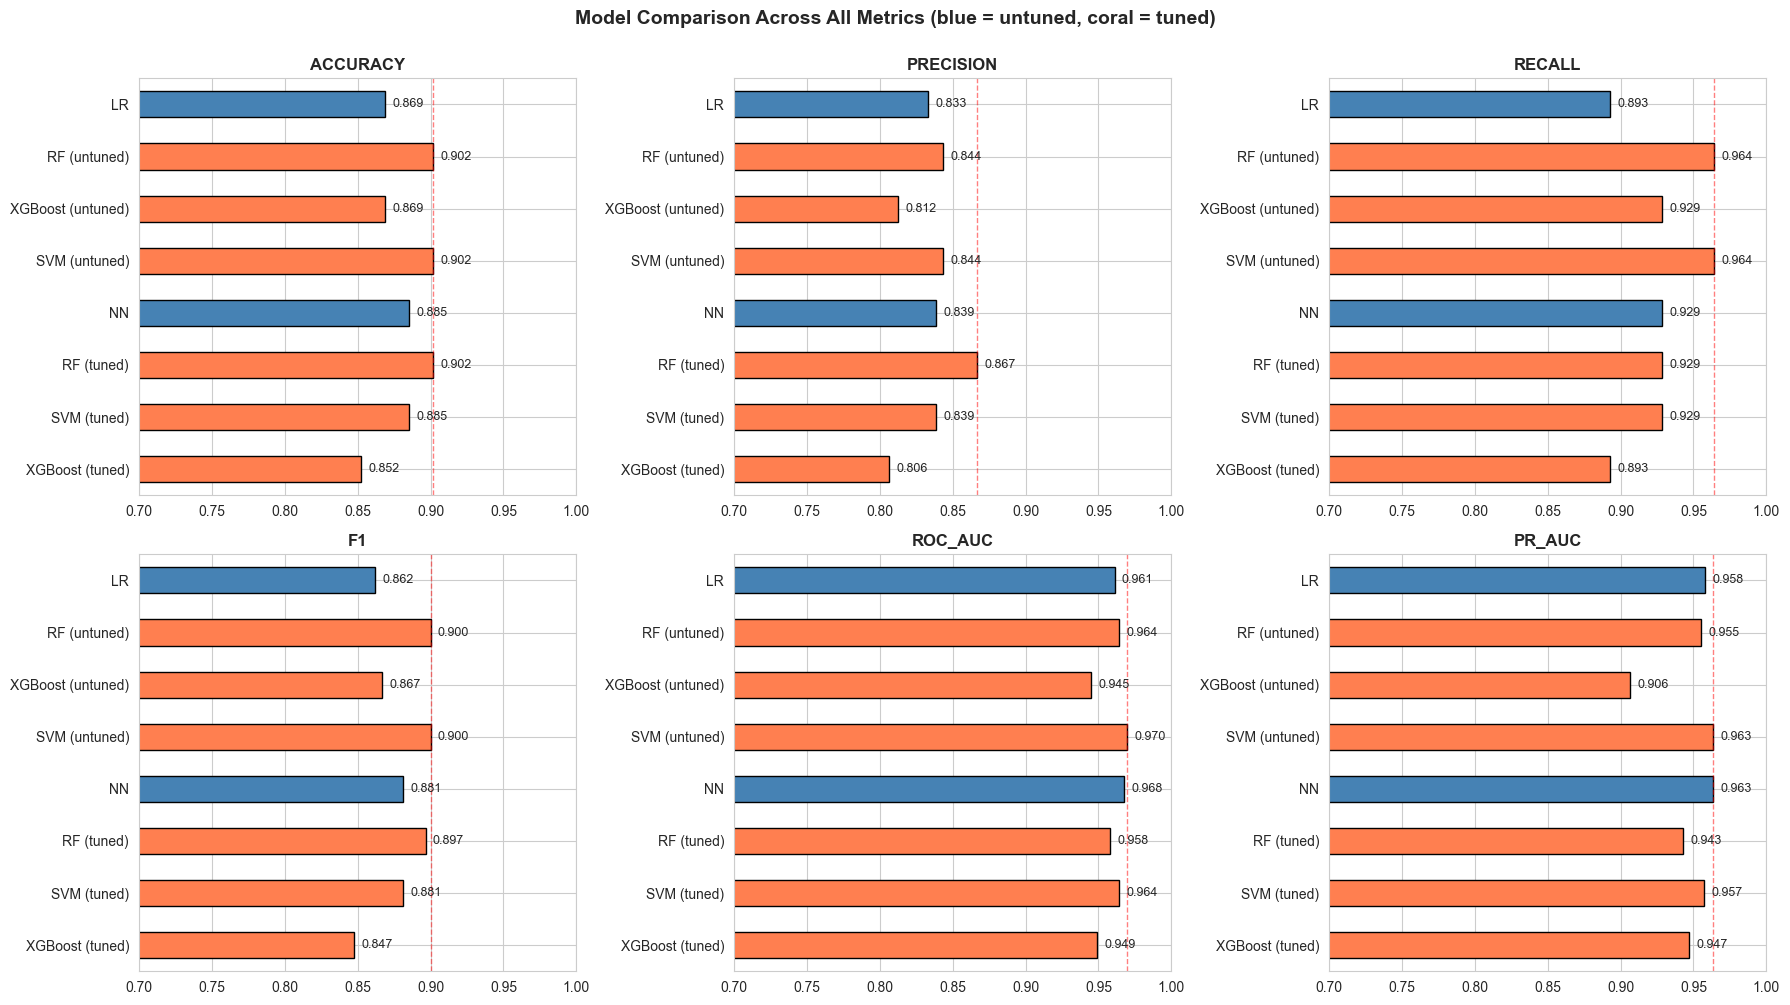


Saved comparison plot to reports/figures/model_comparison.png


In [26]:
# Cell 25 — Final model comparison
all_results = {
    'LR': lr_metrics,
    'RF (untuned)': rf_metrics,
    'XGBoost (untuned)': xgb_metrics,
    'SVM (untuned)': svm_metrics,
    'NN': nn_metrics,
    'RF (tuned)': rf_tuned_metrics,
    'SVM (tuned)': svm_tuned_metrics,
    'XGBoost (tuned)': xgb_tuned_metrics,
}

results_df = pd.DataFrame(all_results).T
print("All model results:")
print(results_df.round(4))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i // 3, i % 3]
    colors = ['steelblue' if 'tuned' not in name else 'coral' for name in results_df.index]
    results_df[metric].plot(kind='barh', ax=ax, color=colors, edgecolor='black')
    ax.set_title(f'{metric.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlim(0.7, 1.0)
    ax.axvline(results_df[metric].max(), color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.invert_yaxis()
    for j, v in enumerate(results_df[metric].values):
        ax.text(v + 0.005, j, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('Model Comparison Across All Metrics (blue = untuned, coral = tuned)',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../reports/figures/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nSaved comparison plot to reports/figures/model_comparison.png")